# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'acm18'  # <-- set this
d = np.genfromtxt(f'{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.19 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

Text(0, 0.5, 'Flux')

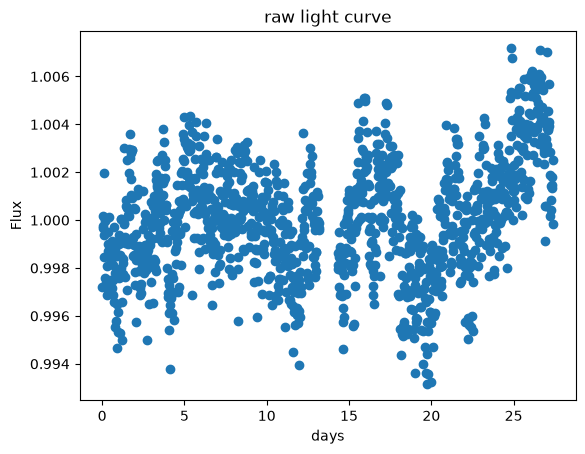

In [2]:
# Part 1: your work here
plt.scatter(t,flux)
# plt.errorbar(t, flux, yerr=sigma, fmt='o', capsize=3)
plt.title('raw light curve');plt.xlabel('days');plt.ylabel('Flux')

Looking at this data set there are a few large trends. From days 0-10 the data forms a bump like the first half of a sin wave. The data from day 20 to the end rises steadily above the maximum of the first bump. From days 10-20 it looks like the data trends upwards but it is very noisy and it includes the daylong gap in the data.

Things that could be transits can be seen on days one, day 15 and day 22. These look like a clusture of lowered points in the data but it is very hard to tell with the underlying trend in the background.

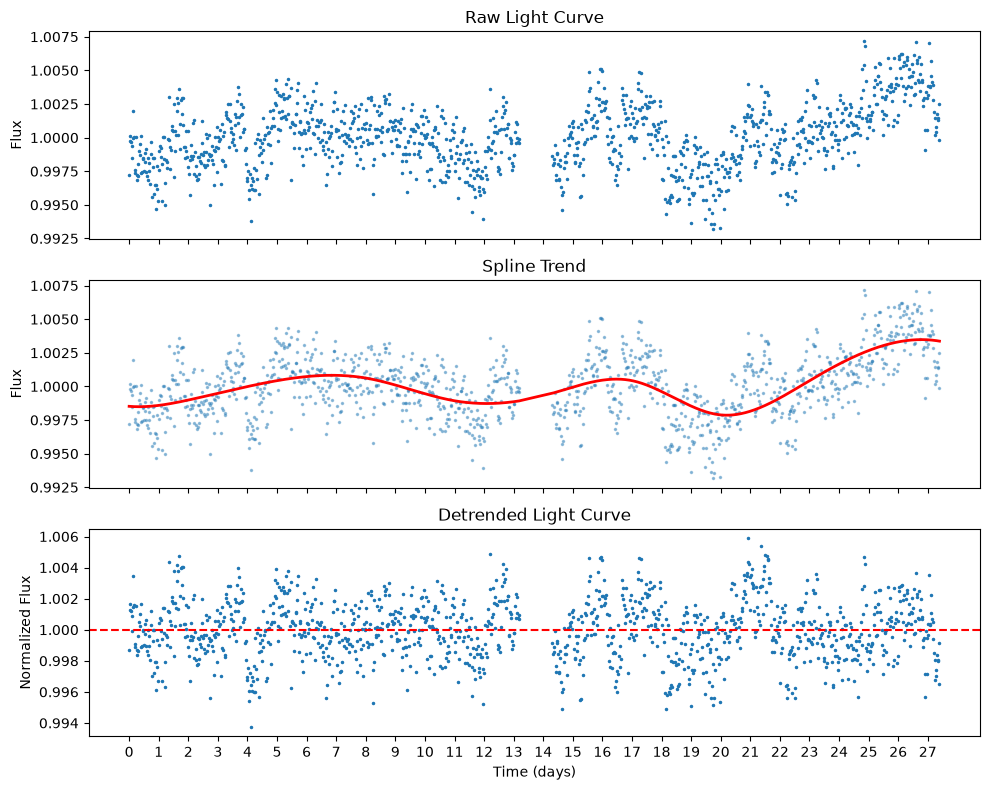

In [3]:
from scipy.interpolate import LSQUnivariateSpline

# knots every 3 days
knots = np.arange(2, 26, 3)

spline = LSQUnivariateSpline(t, flux, knots, k=3)
trend = spline(t)

d_flux = flux/trend

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t, flux, '.', ms=3)
ax[0].set_ylabel("Flux")
ax[0].set_title("Raw Light Curve")

ax[1].plot(t, flux, '.', alpha=0.4, ms=3)
ax[1].plot(t, trend, 'r', lw=2)
ax[1].set_ylabel("Flux")
ax[1].set_title("Spline Trend")

ax[2].plot(t, d_flux, '.', ms=3)
ax[2].axhline(1.0, color='r', ls='--')
ax[2].set_xticks(np.arange(0, 28, 1))
ax[2].set_xlabel("Time (days)")
ax[2].set_ylabel("Normalized Flux")
ax[2].set_title("Detrended Light Curve")

plt.tight_layout()


The method I chose to use is a cubic spline with knots every 3 days. To make sure my smoothing scale can't eat my transits, I kept the knot spacing much longer than the transit duration estimated from the raw data. Also by keeping the knot spacing large I removed only the long systematic trends found in my data. I determined that the spline was the most effective method to remove only the systematic trend after expirimenting with median filters. I found that this cubic spline did the best job in removing only the systematics and not any smaller variations in the data

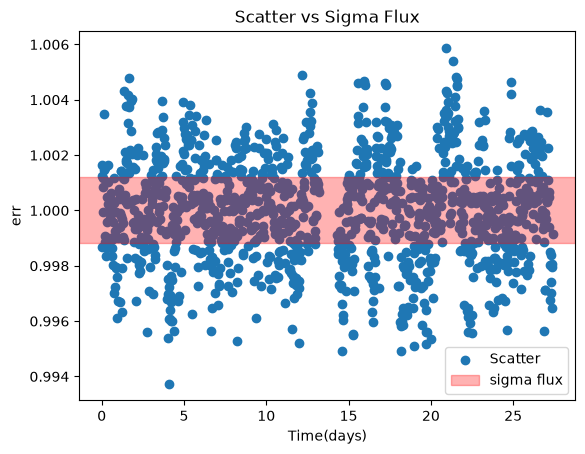

In [18]:

plt.scatter(t, d_flux, label='Scatter')
plt.axhspan(1+sigma[0], 1- sigma[0], color = 'red',alpha=.3,label = 'sigma flux')

plt.title('Scatter vs Sigma Flux');plt.ylabel('err');plt.xlabel('Time(days)');plt.legend()


**ANSWERS (initial guesses + scatter check):**

My initial guess for $(t_0, P, \delta, T)$ is:

$t_0$ =1.2

$P$ = 7.01

$\delta$ = .004

$T$ = .25

The out of transit scatter is much larger than the reported sigma flux, therefore these two measurments are not consistent. It appears that the repoted sigmas are way underestimated when comparing them to the actual residuals.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

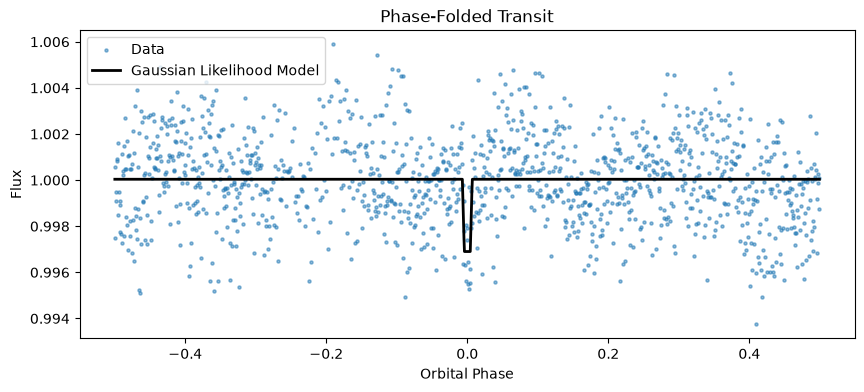

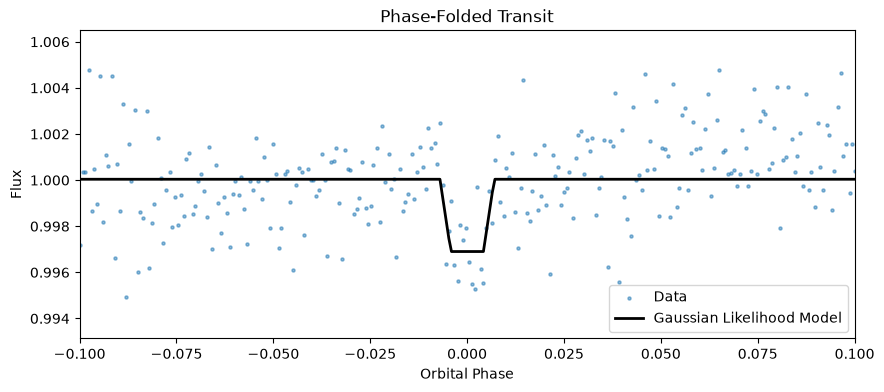

In [5]:
# Part 2: your work here
def neg_gauss_log_likelihood(theta, t,flux,sigma):
    t0,P,delt,T,F = theta
    model = transit_model(t, t0, P, delt, T, F)
    return 0.5 * np.sum(((flux - model)/sigma)**2 + np.log(2*np.pi*sigma**2))

theta0 = [1.2,7.01,.004,.25,1]
result = minimize(neg_gauss_log_likelihood, theta0, args=(t,d_flux,sigma), method='Nelder-Mead')
mm_t0,mm_P,mm_delt,mm_T,mm_F = result.x

gauss_model = transit_model(t, mm_t0, mm_P, mm_delt, mm_T, mm_F)
phase = ((t - mm_t0 +.5*mm_P)%mm_P)/mm_P -0.5

idx = np.argsort(phase)

sphase = phase[idx]
smodel = gauss_model[idx]
sflux = d_flux[idx]


plt.figure(1,figsize=(10, 4))
plt.scatter(sphase,sflux,s=5,alpha=0.5,label="Data")

plt.plot(sphase,smodel,color='k',lw=2, label = 'Gaussian Likelihood Model')
plt.xlabel("Orbital Phase");plt.ylabel('Flux');plt.title("Phase-Folded Transit");plt.legend()

plt.figure(2,figsize=(10,4))
plt.xlim(-.1,.1)
plt.scatter(sphase,sflux,s=5,alpha=0.5,label="Data")

plt.plot(sphase,smodel,color='k',lw=2, label = 'Gaussian Likelihood Model')
plt.xlabel("Orbital Phase");plt.ylabel('Flux');plt.title("Phase-Folded Transit");plt.legend()


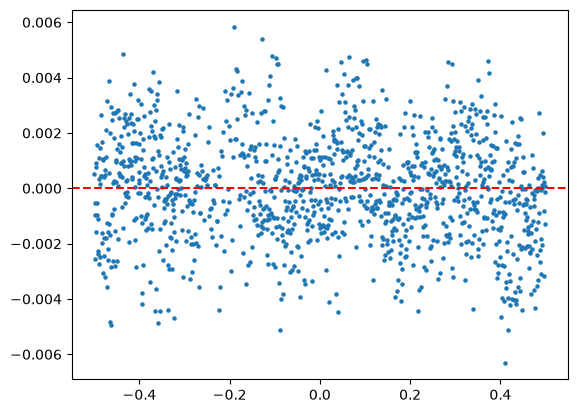

In [6]:
resid = d_flux - gauss_model

plt.scatter(sphase,resid[idx],s=5,label = 'residuals')
plt.axhline(0,color = 'r',linestyle = '--')

In [7]:
'''Hessian Erorr Approximation'''
# t0,P,delt,T,F
def hessian(func, theta, x,flux,sigma, eps=1e-5):
    n = len(theta)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            di = np.zeros(n)
            dj = np.zeros(n)
            di[i] = eps
            dj[j] = eps

            H[i,j] = (func(theta + di + dj, x,flux,sigma) - func(theta + di - dj, x,flux,sigma) - func(theta - di + dj, x,flux,sigma) + func(theta - di - dj, x,flux,sigma))/(4*eps**2)
    return H

H = hessian(neg_gauss_log_likelihood, result.x,t,d_flux,sigma)

cov = np.linalg.inv(H)

H_t0_sig  = np.sqrt(cov[0,0])
H_P_sig = np.sqrt(cov[1,1])
H_delt_sig = np.sqrt(cov[2,2])

print(f"Hessian Computed Errors: \nt0 = {mm_t0:.2f} ± {H_t0_sig:.6f}\nP = {mm_P:.2f} ± {H_P_sig:.6f}\ndelt = {mm_delt:.6f} ± {H_delt_sig:.6f}")

Hessian Computed Errors: 
t0 = 1.23 ± 0.001200
P = 7.00 ± 0.000956
delt = 0.003134 ± 0.000322


In [8]:
'''Point Bootstrap Approximation'''
rng_bs = np.random.default_rng(9232026)
n_boot = 2000

n = len(t)
theta1 = result.x.copy()
boot_t0s = np.empty(n_boot)
boot_Ps = np.empty(n_boot)
boot_delts = np.empty(n_boot)
for i in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    ordr = np.argsort(t[idx])
    tb = t[idx][ordr]
    fb = d_flux[idx][ordr]
    sb = sigma[idx][ordr]
    bs_result = minimize(neg_gauss_log_likelihood, theta1, args=(tb, fb, sb), method='Nelder-Mead')
    mm_t0_bs, mm_P_bs, mm_delt_bs, mm_T_bs, mm_F_bs = bs_result.x
    boot_t0s[i] = mm_t0_bs
    boot_Ps[i] = mm_P_bs
    boot_delts[i] = mm_delt_bs

pbs_t0_sig = np.std(boot_t0s)
pbs_P_sig = np.std(boot_Ps)
pbs_delt_sig = np.std(boot_delts)

print(f"Point Bootstrap Computed Errors: \nt0 = {mm_t0:.2f} ± {pbs_t0_sig:.6f}\nP = {mm_P:.2f} ± {pbs_P_sig:.6f}\ndelt = {mm_delt:.6f} ± {pbs_delt_sig:.6f}")

Point Bootstrap Computed Errors: 
t0 = 1.23 ± 0.007978
P = 7.00 ± 0.008786
delt = 0.003134 ± 0.000428


In [9]:
'''Block Boostrap Approximation'''

boot_t0s = np.full(n_boot,np.nan)
boot_Ps = np.full(n_boot,np.nan)
boot_delts = np.full(n_boot,np.nan)

block_size = 48
n_blocks = int(np.ceil(n / block_size))

t01, p1, delt1, T1, F1 = theta1

best_model = transit_model(t,t01,p1,delt1,T1,F1)
bbs_resid = d_flux - best_model
for i in range(n_boot):

    starts = rng_bs.integers(0,n - block_size,size=n_blocks)
    resid_idx = np.concatenate([np.arange(s, s + block_size)for s in starts])[:n]
  
    flux_bs = best_model + resid[resid_idx]
    bs_result = minimize(neg_gauss_log_likelihood, theta1, args=(t, flux_bs, sigma), method='Nelder-Mead')
    mm_t0_bs, mm_P_bs, mm_delt_bs, mm_T_bs, mm_F_bs = bs_result.x
    boot_t0s[i] = mm_t0_bs
    boot_Ps[i] = mm_P_bs
    boot_delts[i] = mm_delt_bs

bbs_t0_sig = np.nanstd(boot_t0s, ddof=1)
bbs_P_sig = np.nanstd(boot_Ps,ddof=1)
bbs_delt_sig = np.nanstd(boot_delts,ddof=1)

print(f"Block Bootstrap Computed Errors: \nt0 = {mm_t0:.2f} ± {bbs_t0_sig:.6f}\nP = {mm_P:.2f} ± {bbs_P_sig:.6f}\ndelt = {mm_delt:.6f} ± {bbs_delt_sig:.6f}")


Block Bootstrap Computed Errors: 
t0 = 1.23 ± 0.010444
P = 7.00 ± 0.048345
delt = 0.003134 ± 0.000692


Single-point scatter: 0.0018823644666617933
Expected 5-hr scatter: 0.0005952559101219354
Measured 5-hr scatter: 0.0012826315695380066
Ratio measured/expected = 2.1547565471046988


Text(0.5, 1.0, '5-Hour Binned Residuals')

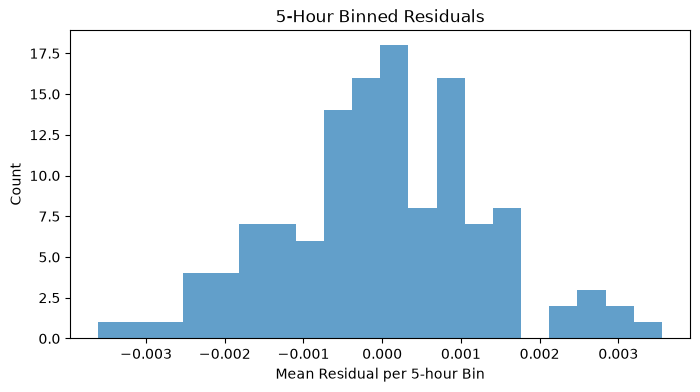

In [10]:
resid = d_flux - gauss_model

# ~5 hour bins
bin_size = 10

n_bins = len(resid) // bin_size

# trim extra points
resid_trim = resid[:n_bins * bin_size]
# reshape into bins
resid_bins = resid_trim.reshape(n_bins, bin_size)
# average each bin
binned_resid = np.mean(resid_bins, axis=1)
# measured scatter
sigma_binned_measured = np.std(binned_resid)
# expected scatter for independent noise
sigma_single = np.std(resid)
sigma_binned_expected = sigma_single / np.sqrt(bin_size)

print("Single-point scatter:", sigma_single)
print("Expected 5-hr scatter:", sigma_binned_expected)
print("Measured 5-hr scatter:", sigma_binned_measured)
print("Ratio measured/expected =", sigma_binned_measured / sigma_binned_expected)

plt.figure(figsize=(8,4))

plt.hist(binned_resid,bins=20,alpha=0.7)

plt.xlabel("Mean Residual per 5-hour Bin")
plt.ylabel("Count")
plt.title("5-Hour Binned Residuals")

**FINAL ANSWER:** $\delta = $ _3.13_ $\pm$ _.0692_ ppt, $P = $ _7.00_ $\pm$ _0.0483_ d, $t_0 = $ _1.23_ $\pm$ _0.01044_ d

**Which uncertainty and why (a short paragraph):**

The hessian and signle point bootstrap(pbs) both assume that the residuals and independent and uncorrelated between points. That would be a fine assumption if the data wasn't a time stream. Since the data is an underlyingg trend plus the transient event every 7 days, the residuals contain time correlated noise that is dependent on neighboring measurments. I checked this concept above the 5-hour histogram, independent gaussian noise for the 5 hour bins should look like 1/(N)**.5. As we can see that noise is more than two times the expected value signifying that the residuals contain correlated noise. Since pbs and the hessian don't account for correlated noise I am reporting the error from the block boostrap to make sure my error is not underestimated like in the given data.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:* Median window is way too short

*Flaw 2:* Reports error that misses the correlated noise

*Flaw 3:* Impropely reestimates the noise by assuming that noise is not correlated

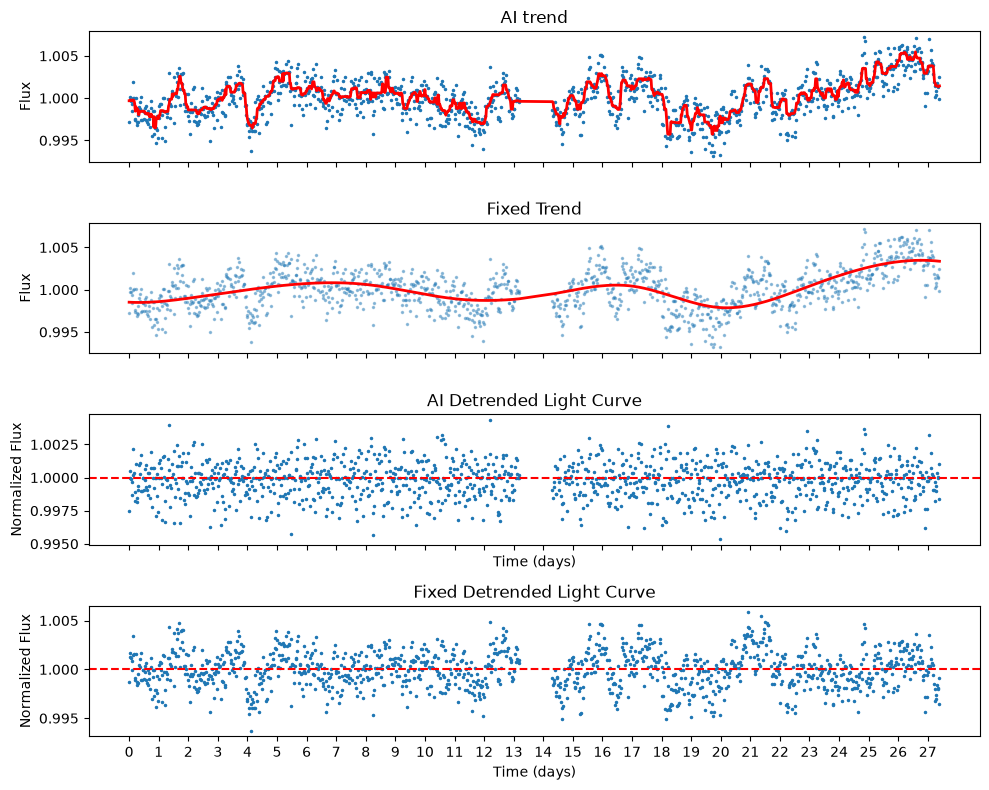

In [11]:
# Part 3: demonstrations here
'''Short Median Window'''
 #AI soulution
from scipy.ndimage import median_filter

cadence = np.median(np.diff(t))
window = max(3, int(round((6.0 / 24.) / cadence)))
ai_trend = median_filter(flux, size=window)
flux_detrended = flux - ai_trend + 1.0
#End AI Code


fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t, flux, '.', ms=3)
ax[0].plot(t, ai_trend, 'r', lw=2)
ax[0].set_ylabel("Flux")
ax[0].set_title("AI trend")

ax[1].plot(t, flux, '.', alpha=0.4, ms=3)
ax[1].plot(t, trend, 'r', lw=2)
ax[1].set_ylabel("Flux")
ax[1].set_title("Fixed Trend")

ax[3].plot(t, d_flux, '.', ms=3)
ax[3].axhline(1.0, color='r', ls='--')
ax[3].set_xticks(np.arange(0, 28, 1))
ax[3].set_xlabel("Time (days)")
ax[3].set_ylabel("Normalized Flux")
ax[3].set_title("Fixed Detrended Light Curve")

ax[2].plot(t, flux_detrended, '.', ms=3)
ax[2].axhline(1.0, color='r', ls='--')
ax[2].set_xticks(np.arange(0, 28, 1))
ax[2].set_xlabel("Time (days)")
ax[2].set_ylabel("Normalized Flux")
ax[2].set_title("AI Detrended Light Curve")


plt.tight_layout()

#### Detrending

In the AI solution a detrending method of a median filter is choosen, on its own this is ok but the error comes from choosing a filter window that is much too small. The initial guess for the transit duration was .25 d or ~ 6 hours. In order to preserve the transit data when subtracting the systematic trend you need to choose a smoothing scale that is much larger than this value. That is why I use 3 days for my smoothing scale, it is small enough that it can still track the large changes while not being so large that you miss the underlying trend. In the plot above you can clearly see that using the larger smoothing scale in my "fixed detrended light curve" plot preserves the transets way better than the AI version. When I fit my model it is to real data, the AI turned its data into noise. The proper method is to use a smoothing scale larger than the transiet events that cleary captures the underlying trend when plotted.

In [12]:
'''Correlated Noise'''
print("Single-point scatter:", sigma_single)
print("Expected 5-hr scatter:", sigma_binned_expected)
print("Measured 5-hr scatter:", sigma_binned_measured)
print("Ratio measured/expected =", sigma_binned_measured / sigma_binned_expected)

Single-point scatter: 0.0018823644666617933
Expected 5-hr scatter: 0.0005952559101219354
Measured 5-hr scatter: 0.0012826315695380066
Ratio measured/expected = 2.1547565471046988


#### Correlated Noise

The AI reports noise from calculating the Hessian around the maxima of the likelyhood model. This is a valid way of computing error if each data point was uncorrelated. This specific data set does not meet that criteria and I demonstrated that in Part 2. The residuals contain time correlated noise meaning that neighboring measurments are not independent. To furthure prove this point you can bin the residuals into 5 hour bins. If the error was uncorrelated the std of the residuals should equal the std of the means for the binned residuals, this is not the case. Instead the binned residuals have 2x the non binned std because the errors correlate with the position of the point.  The proper method is to use a blocked boostrap to take into account that errors are correlated locally, block by ~day or slightly longer than a transit.

Text(0.5, 1.0, '5-Hour Binned Residuals')

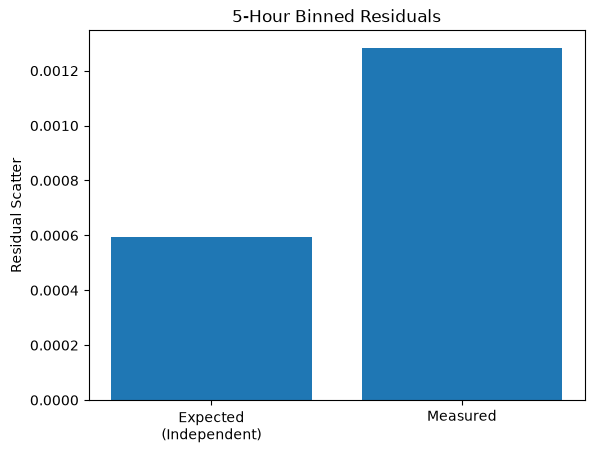

In [13]:
'''Improper systematic reestimation'''
plt.bar(["Expected\n(Independent)", "Measured"],[sigma_binned_expected, sigma_binned_measured])

plt.ylabel("Residual Scatter")
plt.title("5-Hour Binned Residuals")

#### Improper Systematic Reestimation

In the AI step 2 it reestimates noise empirically as the stter of the detrended lightcurve claiming "This automatically
accounts for any excess noise in the data and guarantees a self-consistent error model." What the AI failed to take into account is that the noise is correlated and not independent for each point. I performed this analysis in Part 2 but have provided a box plot above. The expected noise comes from the stds of the residuals, this is the method the AI used that assumes each points noise is independent of the others. The measured bar is the std if the data was binned every 5 hours, as we can see this is about twice the expected scatter. This is because the error of a point is correlated with it's position relative to the other points. The proper step is to estimate your error with a blocked bootstrap once you have designed a model.

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

I created an Agent in copilot to be used specifically for this class and gave it the textbooks and github as knowledge for it to be trained on. I first used it to help me understand what the prompt was asking for and then had it provide a median filter algorithm. I did not copy its code but I adopted it into my personal style in order to catch any posible errors. It reccomended a window size of 1 day for the median filter which is too short for this data. I was able to catch it and the determine the proper window size myself.

I had the agent help me create the log likelihood model for part 2 and the histogram for part 2.3. Both of these were done correctly and I modified to fit my personal style. 

When asking the AI how to make my boostrap more efficient it recomended cutting the number of samples to 500, that is just too short. I used the AI model to check my code in part 2 to ensure to errors and to sanity check my output

I used the AI to speed up some of the coding for parts 2 and 3 of my varificarion plan. I learned that copilot is very bad at format strings and will often leave out characters and brackets.

I let the AI double check my entire report and it cought that I has computing my block bootstrap by resampling the data and not the residuals like instructed. I modified the AI's corrected code into my pipeline to make sure I am reporting error correctly

**VERIFICATION PLAN:**

I am going to write a verification plan that checks detrending robustness, optimizer stability and an injection-Recovery test. Could you provide the code for the injection recovery test?

I will be performing three checks for my Verification Plan: Detrending robustness, do I get the same values if I use a different reasonable detrending method like median filter; optimizer stability, do I converge on the same predicted values if I change my optimizers initial guess;simulated data, does my model work when I know the true values. Failure for the detrending robustness would be if the median filtered data converges on a new fit. Failure for optimizer stability would show wildly varying results for $\delta$, $P$, and $t_0$ when I vary the initial guess. Failure for the simulated data is if my model converges on the wrong solution.

In [14]:
'''Detrending robustness'''
from scipy.signal import medfilt
ppd = 48 # 48 points per day
k_size = 3 * ppd + 1 # 145 points, odd as required
 
mtrend = medfilt(flux, kernel_size=k_size)
md_flux = flux / mtrend

mresult = minimize(neg_gauss_log_likelihood, theta0, args=(t,md_flux,sigma), method='Nelder-Mead')
mmm_t0,mmm_P,mmm_delt,mmm_T,mmm_F = mresult.x


print(f"Splice: \nt0 = {mm_t0:.2f} \nP = {mm_P:.2f}\ndelt = {mm_delt:.6f}")
print(f"mean: \nt0 = {mmm_t0:.2f} \nP = {mmm_P:.2f}\ndelt = {mmm_delt:.6f}")


Splice: 
t0 = 1.23 
P = 7.00
delt = 0.003134
mean: 
t0 = 0.96 
P = 7.14
delt = 0.001440


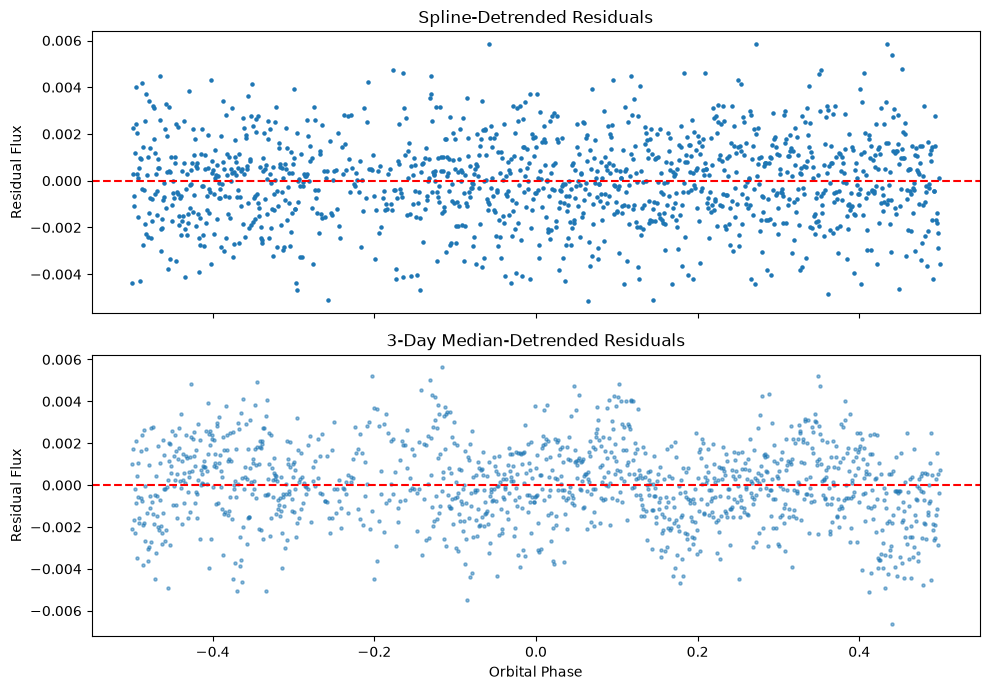

In [15]:
# Fit spline-detrended data
median_model = transit_model(t, mmm_t0, mmm_P, mmm_delt, mmm_T, mmm_F)
median_resid = md_flux - median_model
median_phase = ((t - mmm_t0 + 0.5 * mmm_P) % mmm_P) / mmm_P - 0.5


# Plot residuals
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax[0].scatter(sphase,resid[idx],s=5,label = 'residuals')
ax[0].axhline(0,color = 'r',linestyle = '--')
ax[0].set_ylabel("Residual Flux")
ax[0].set_title("Spline-Detrended Residuals")

ax[1].scatter(median_phase, median_resid, s=5, alpha=0.5)
ax[1].axhline(0, color="red", linestyle="--")
ax[1].set_xlabel("Orbital Phase")
ax[1].set_ylabel("Residual Flux")
ax[1].set_title("3-Day Median-Detrended Residuals")

plt.tight_layout()
plt.show()

The detrending robustness test fails because the two filtering methods produced different fitted values for the parameters. This indicates that the transit parameters are sensitive to the treatment of the underlying systematics. Instead the model that I chose for my analysis was spline because it provided a residual plot with less underlying structure.

In [16]:
'''Optimizer stability'''

# Test several initial guesses
initial_guesses = [[1.15, 6.95, 0.002, 0.08, 1.0],
    [1.20, 7.01, 0.004, 0.10, 1.0],
    [1.25, 7.05, 0.003, 0.15, 1.0],
    [1.30, 6.98, 0.005, 0.25, 1.0],
    [1.20, 7.10, 0.002, 0.45, 1.0]]

stability_results = []

for theta0 in initial_guesses:

    test_result = minimize(
        neg_gauss_log_likelihood,
        theta0,
        args=(t, d_flux, sigma),
        method="Nelder-Mead",
        options={"maxiter": 5000}
    )

    if test_result.success and np.isfinite(test_result.fun):
        stability_results.append([
            *theta0,
            *test_result.x,
            test_result.fun])


# Column order:
# initial t0, P, depth, T, F0,
# fitted  t0, P, depth, T, F0,
# negative log-likelihood

stability_results = np.array(stability_results)
print(
    "Initial guesses                 "
    "Recovered parameters                         NLL"
)

for row in stability_results:
    (
        start_t0, start_P, start_delt, start_T, start_F,
        fit_t0, fit_P, fit_delt, fit_T, fit_F,
        nll
    ) = row

    print(
        f"start=({start_t0:.2f}, {start_P:.2f}, "
        f"{start_delt:.4f}, {start_T:.2f}, {start_F:.4f})  "
        f"fit=({fit_t0:.4f}, {fit_P:.4f}, "
        f"{fit_delt:.6f}, {fit_T:.4f}, {fit_F:.6f})  "
        f"NLL={nll:.2f}"
    )

Initial guesses                 Recovered parameters                         NLL
start=(1.15, 6.95, 0.0020, 0.08, 1.0000)  fit=(1.2318, 7.0048, 0.003130, 0.0982, 1.000037)  NLL=-5765.66
start=(1.20, 7.01, 0.0040, 0.10, 1.0000)  fit=(1.2319, 7.0047, 0.003109, 0.0983, 1.000036)  NLL=-5765.65
start=(1.25, 7.05, 0.0030, 0.15, 1.0000)  fit=(1.2478, 7.0095, 0.002132, 0.1711, 1.000040)  NLL=-5748.53
start=(1.30, 6.98, 0.0050, 0.25, 1.0000)  fit=(0.9376, 7.1458, 0.001373, 0.4583, 1.000077)  NLL=-5758.23
start=(1.20, 7.10, 0.0020, 0.45, 1.0000)  fit=(0.9375, 7.1458, 0.001371, 0.4583, 1.000076)  NLL=-5758.23


My model fails the optimizer stability test specifically when considering depth and duration. The values I report in part 2 do correlate to the guess with the smallest NLL so that adds confidence that my model is correct in this specific case but it does mean that my model is not robust for all cases. The multiple minima of the likelyhood makes me feel like this is not the best method to estimate these parameters.

In [17]:
''' Injection-Recovery Test '''

rng = np.random.default_rng(9232026)

# choose known parameters
inj_t0    = 1.25
inj_P     = 7.00
inj_depth = 0.0030
inj_T     = 0.10
inj_F0    = 1.0

# generate noiseless transit model
flux_true = transit_model(t,inj_t0,inj_P,inj_depth,inj_T,inj_F0)

# add Gaussian noise
flux_sim = flux_true + rng.normal(0, np.mean(sigma), len(t))

theta0 = [1.2, 7.0, 0.004, 0.25, 1.0]

result_sim = minimize(neg_gauss_log_likelihood,theta0,args=(t, flux_sim, sigma),method='Nelder-Mead')

rec_t0, rec_P, rec_depth, rec_T, rec_F0 = result_sim.x

vn_boot = 1000
vboot_t0s = np.full(vn_boot,np.nan)
vboot_Ps = np.full(vn_boot,np.nan)
vboot_delts = np.full(vn_boot,np.nan)
vboot_Ts = np.full(vn_boot,np.nan)

theta2 = result_sim.x.copy()

block_size = 48
n_blocks = int(np.ceil(n / block_size))

t02, p2, delt2, T2, F2 = theta2

best_model = transit_model(t,t02,p2,delt2,T2,F2)
bbs_resid = flux_sim - best_model
for i in range(vn_boot):

    starts = rng_bs.integers(0,n - block_size,size=n_blocks)
    resid_idx = np.concatenate([np.arange(s, s + block_size)for s in starts])[:n]
    
    flux_bs = best_model + resid[resid_idx]
    bs_result = minimize(neg_gauss_log_likelihood, theta1, args=(t, flux_bs, sigma), method='Nelder-Mead')
    mm_t0_bs, mm_P_bs, mm_delt_bs, mm_T_bs, mm_F_bs = bs_result.x
    vboot_t0s[i] = mm_t0_bs
    vboot_Ps[i] = mm_P_bs
    vboot_delts[i] = mm_delt_bs
    vboot_Ts[i] = mm_T_bs

vbbs_t0_sig = np.nanstd(vboot_t0s, ddof=1)
vbbs_P_sig = np.nanstd(vboot_Ps, ddof=1)
vbbs_delt_sig = np.nanstd(vboot_delts, ddof=1)
vbbs_T_sig = np.nanstd(vboot_Ts, ddof=1)

print("Injected Parameters")
print("-------------------")
print(f"t0    = {inj_t0}")
print(f"P     = {inj_P}")
print(f"depth = {inj_depth}")
print(f"T     = {inj_T}")
print()

print("Recovered Parameters")
print("-------------------")
print(f"t0    = {rec_t0:.4f} ± {vbbs_t0_sig:.6f}")
print(f"P     = {rec_P:.4f} ± {vbbs_P_sig:.6f}")
print(f"depth = {rec_depth:.5f} ± {vbbs_delt_sig:.6f}")
print(f"T     = {rec_T:.4f} ± {vbbs_T_sig:.6f}")

Injected Parameters
-------------------
t0    = 1.25
P     = 7.0
depth = 0.003
T     = 0.1

Recovered Parameters
-------------------
t0    = 1.2931 ± 0.062405
P     = 7.0030 ± 0.167609
depth = 0.00126 ± 0.000641
T     = 0.2708 ± 0.105473


My model fails the simulated data test for two parameters, depth and T. This is a failure because the ture value was not included in the reported error bounds because the estimated value is far from the real one. I believe that this is from my data having multiple local minima in the likelyhood function. A solution for this would be to test many sets of initial conditions and hope that one aligns with the true value but that is based more on luck than data to try and contain something close enough to the true value in my initial guesses. In my actual model I tried many initial conditions and watched how the the NLL value changed, the current iteration is the model with the smallest NLL which should correspond to the true minima. This is the best I can think to do short of testing a large amount of initial conditions and checking the minimum likelyhood value for each of them. Combine this with the optimizer stability test and we can recover that initial guesses are extreemly important to my model.